## Student Performance Indicator


#### Life cycle of Machine learning Project

- Understanding the Problem Statement
- Data Collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### 1) Problem statement
- This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.


### 2) Data Collection
- Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
- The data consists of 8 column and 1000 rows.

In [ ]:
# Import packages / libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
#import data 

df=pd.read_csv("data/StudentsPerformance.csv")

In [8]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [10]:
df.shape

(1000, 8)

### 2.2 Dataset information

- gender : sex of students  -> (Male/female)
- race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
- parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
- lunch : having lunch before test (standard or free/reduced) 
- test preparation course : complete or not complete before test
- math score
- reading score
- writing score

### 3. Data Checks to perform

- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

In [11]:
#Check missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [12]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [17]:
#check no of unique values in cols
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [ ]:
#statistic of dataset
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight
- From above description of numerical data, all means are very close to each other - between 66 and 68.05;
- All standard deviations are also close - between 14.6 and 15.19;
- While there is a minimum score  0 for math, for writing minimum is much higher = 10 and for reading myet higher = 17

In [21]:
#explore data
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [22]:
def print_categories(df):
    categorical_col=df.select_dtypes(include='object').columns

    for col in categorical_col:
        print(f"\nColumn : {col}")
        print(df[col].unique())
        print(f'Number of categories : {df[col].nunique()}')

In [23]:
print_categories(df)


Column : gender
['female' 'male']
Number of categories : 2

Column : race/ethnicity
['group B' 'group C' 'group A' 'group D' 'group E']
Number of categories : 5

Column : parental level of education
["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Number of categories : 6

Column : lunch
['standard' 'free/reduced']
Number of categories : 2

Column : test preparation course
['none' 'completed']
Number of categories : 2


In [27]:
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']

print("we have {} numerical_features : {}".format(len(numerical_features),numerical_features))
print("we have {} numerical_features : {}".format(len(categorical_features),categorical_features))

we have 3 numerical_features : ['math score', 'reading score', 'writing score']
we have 5 numerical_features : ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [ ]:
df.head(2)d

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88


In [29]:
#adding columns for total score and average score
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average_score']=df['total_score'] / 3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [42]:
#Number of students with full marks
math_full=(df['math score']==100).sum()
reading_full=(df['reading score']==100).sum()
writing_full=(df['writing score']==100).sum()

print("Number of students with full marks in maths : ",math_full)
print("Number of students with full marks in reading : ",reading_full)
print("Number of students with full marks in writing : ",writing_full)

Number of students with full marks in maths :  7
Number of students with full marks in reading :  17
Number of students with full marks in writing :  14


In [45]:
math_less_20=(df['math score']<20).sum()
reading_less_20=(df['reading score']<20).sum()
writing_less_20=(df['writing score']<20).sum()

print("Number of students scored less than 40 in maths : ",math_less_20)
print("Number of students scored less than 40 in reading : ",reading_less_20)
print("Number of students scored less than 40 in writing : ",writing_less_20)

Number of students scored less than 40 in maths :  4
Number of students scored less than 40 in reading :  1
Number of students scored less than 40 in writing :  3


#####  Insights
 - From above values we get students have performed the worst in Maths 
 - Best performance is in reading section

### 4. Exploring Data ( Visualization )
#### 4.1 Visualize average score distribution to make some conclusion. 
- Histogram
- Kernel Distribution Function (KDE)

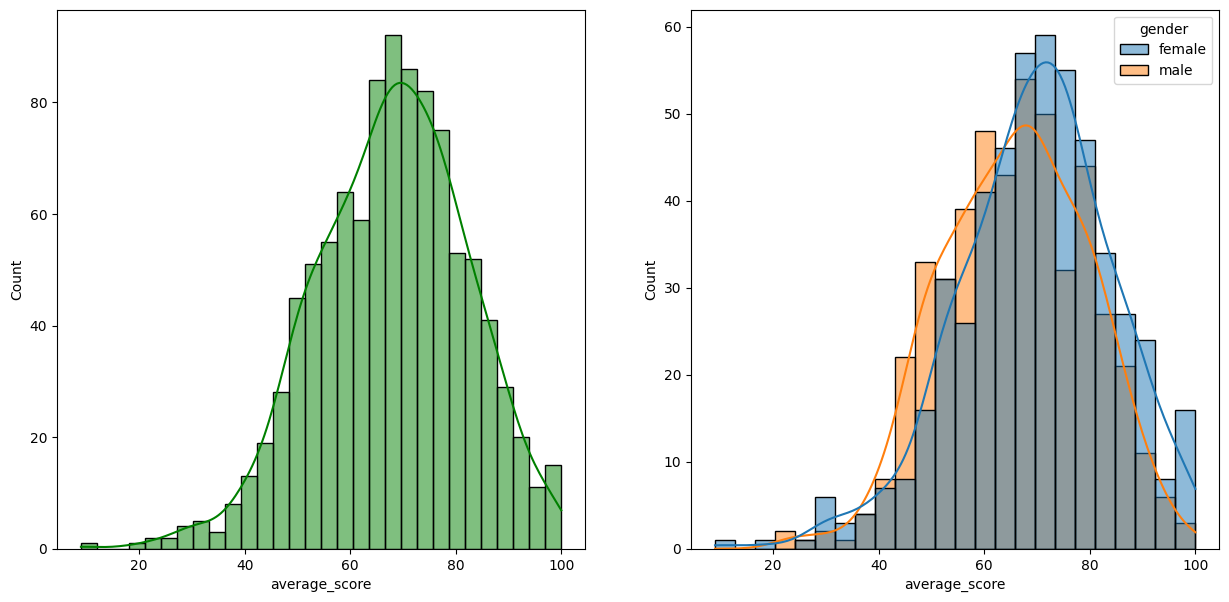

In [48]:
# Distribution of Average Scores and Gender-wise Comparison
fig , axs =plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='average_score',bins=30,kde=True,color='g')
plt.subplot(1,2,2)
sns.histplot(data=df,x='average_score',hue='gender',kde=True)
plt.show()

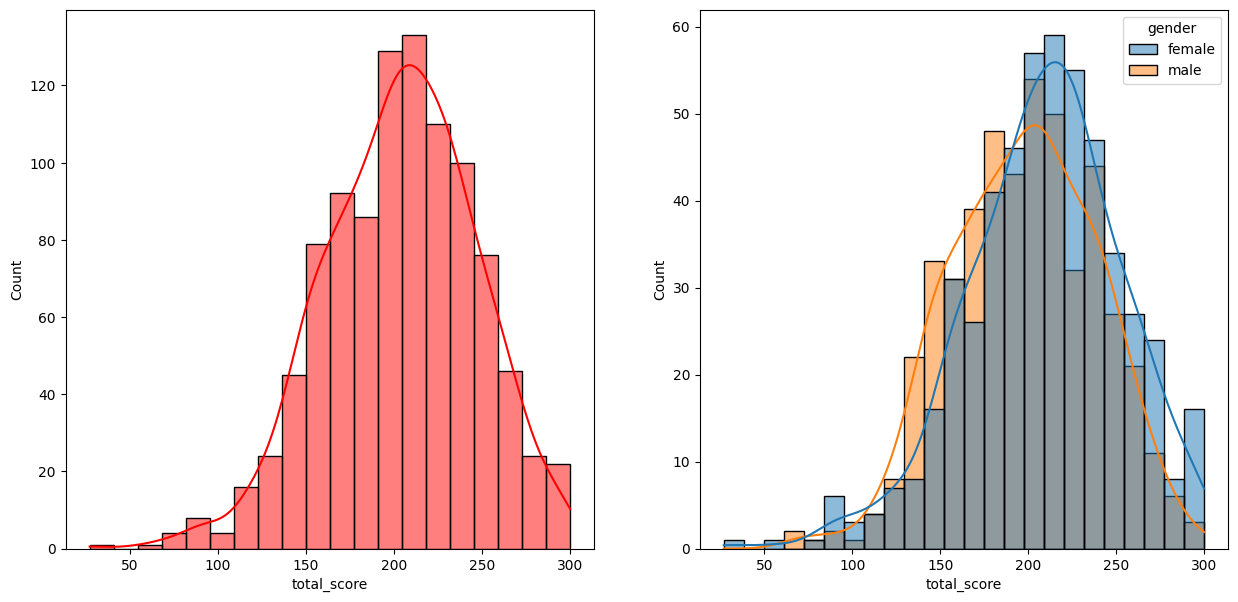

In [49]:
fig , axs = plt.subplots(1,2,figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df,x='total_score',kde=True,bins=20,color='r')
plt.subplot(1,2,2)
sns.histplot(data=df,hue='gender',x='total_score',kde=True)
plt.show()

#####  Insights
- Total scores are approximately normally distributed.
- Most students scored between 180 and 240.
- Female students have slightly higher total scores than male students.
- The performance difference between males and females is small due to significant overlap.
